In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import squidpy as sq
import torch

import sys
sys.path.append("../")
import steamboat as sf
import steamboat.tools

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['mathtext.fontset'] = 'dejavuserif'
matplotlib.rcParams['font.family'] = 'arial'
matplotlib.rcParams["legend.handletextpad"] = 0.
matplotlib.rcParams["legend.labelspacing"] = .3
pltkw = dict(bbox_inches='tight', transparent=True)

c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\spatialdata\_core\query\relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\spatialdata\_core\query\relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = parti

In [2]:
adata = sc.read_h5ad("../../../data/slidetags/HumanTonsil_2000.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 5778 × 2000
    obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'cluster'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cluster_colors', 'hvg', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [4]:
adata.obs['global'] = 0
adatas = sf.prep_adatas([adata], norm=False, log1p=False, n_neighs=8)
dataset = sf.make_dataset(adatas, sparse_graph=True, regional_obs=['global'])

  0%|          | 0/1 [00:00<?, ?it/s]

Using None to mask variables. Explicitly specify `mask_var=False` to use all genes.
Using ['global'] as regional annotations.


  0%|          | 0/1 [00:00<?, ?it/s]

In [5]:
device = 'cuda'
sf.set_random_seed(0)
model = sf.Steamboat(adata.var_names.tolist(), n_heads=60, n_scales=3)
model = model.to(device)

In [6]:
# model.fit(dataset.to(device), entry_masking_rate=0.1, feature_masking_rate=0.1,
#             max_epoch=10000, 
#             loss_fun=torch.nn.MSELoss(reduction='sum'),
#             opt=torch.optim.Adam, opt_args=dict(lr=0.1), stop_eps=2e-5, report_per=1000, stop_tol=250, device=device)

# torch.save(model.state_dict(), 'saved_models/tonsil.pth')

# [2025-10-02 12:25:00,171::train::INFO] Epoch 1: train_loss 393.33020
# [2025-10-02 12:25:06,773::train::INFO] Epoch 1001: train_loss 206.91405
# [2025-10-02 12:25:13,339::train::INFO] Epoch 2001: train_loss 203.47221
# [2025-10-02 12:25:19,166::train::INFO] Epoch 2886: train_loss 203.11626
# [2025-10-02 12:25:19,167::train::INFO] Stopping criterion met.

In [7]:
model.load_state_dict(torch.load('saved_models/tonsil.pth'))

<All keys matched successfully>

In [8]:
sf.tools.calc_obs(adatas, dataset, model, get_recon=True)
sf.tools.gather_obs(adata, adatas)

  0%|          | 0/1 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 5778 × 2000
    obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'cluster', 'global'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cluster_colors', 'hvg', 'neighbors', 'pca', 'umap', 'spatial_neighbors', 'global_k_0'
    obsm: 'X_pca', 'X_umap', 'spatial', 'X_recon', 'q', 'local_k', 'global_k_0', 'attn', 'ego_attn', 'local_attn', 'global_attn_0', 'global_attn'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances', 'local_attn_0', 'local_attn_1', 'local_attn_2', 'local_attn_3', 'local_attn_4', 'local_attn_5', 'local_attn_6', 'local_attn_7', 'local_attn_8', 'local_attn_9', 'local_attn_10', 'local_attn_11', 'local_attn_12', 'local_attn_13', 'local_attn_14', 'local_attn_15', 'local_attn_16', '

In [10]:
sf.tools.segment(adata, resolution=0.75, key_added="steamboat_spatial_domain_fine", n_prop=2)

adata.obs['steamboat_spatial_domain_fine'].value_counts()

steamboat_spatial_domain_fine
0    1571
1    1409
2    1298
3    1031
4     380
5      89
Name: count, dtype: int64

c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\squidpy\pl\_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


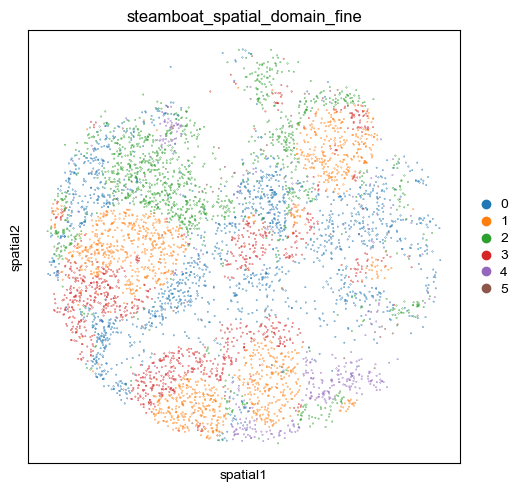

In [12]:
sq.pl.spatial_scatter(adata, color="steamboat_spatial_domain_fine", size=.1, shape=None)


In [14]:
pd.crosstab(adata.obs['steamboat_spatial_domain_fine'], adata.obs['cluster'])

cluster,B_germinal_center,B_memory,B_naive,FDC,NK,T_CD4,T_CD8,T_double_neg,T_follicular_helper,mDC,myeloid,pDC,plasma
steamboat_spatial_domain_fine,,,,,,,,,,,,,
0,50,107,124,34,137,678,166,37,30,114,30,60,4
1,862,3,12,99,8,17,6,1,205,0,18,1,177
2,43,327,751,13,17,41,36,4,24,14,4,2,22
3,853,20,27,26,5,19,15,0,26,0,16,1,23
4,36,58,152,72,3,22,15,4,8,3,3,0,4
5,4,1,1,11,0,2,0,0,1,6,31,0,32


In [15]:
adata.uns['cluster_colors'] = ['#144B99', '#BADEE6', '#7CBDCB', '#866D2B', '#848467', 
                               '#CCAA7A', '#947AB5', '#C6B7D8', '#644B9F', '#E5B7BE',
                               '#CB7988', '#B33E54', '#9A1C29']

In [16]:
adata.obs['steamboat_spatial_domain_2_labeled'] = adata.obs['steamboat_spatial_domain_2'].map({'0': 'GC', '1': 'TZ', '2': 'MZ'}.__getitem__)

c:\Users\lshh\miniconda3\envs\py311_torch211_cuda121\Lib\site-packages\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
c:\Users\lshh\miniconda3\envs\py311_torch211_cuda121\Lib\site-packages\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


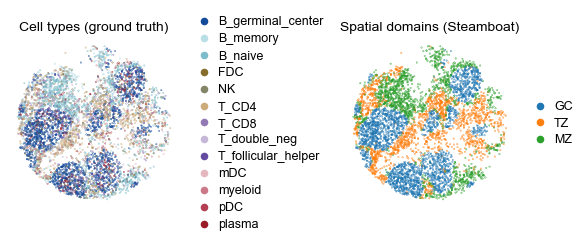

In [17]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(6.5, 2.5))
gs = GridSpec(1, 2, width_ratios=[1, 1.], hspace=.5, wspace=1., figure=fig)
axes = [fig.add_subplot(gs[:, 0])] + [fig.add_subplot(gs[i, 1]) for i in range(1)]

##########################
ax = axes[0]
sq.pl.spatial_scatter(adata, color="cluster", size=.1, shape=None, ax=ax, legend_loc='right margin', frameon=False)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Cell types (ground truth)", size=10)
# ax.legend(handletextpad=0.05)

legend = ax.get_legend()
if legend:
    legend.set_title(legend.get_title().get_text(), prop={'size': 8})  # Adjust legend title size
    for text in legend.get_texts():
        text.set_fontsize(9)  # Adjust legend text size
    for handle in legend.legend_handles:
        handle.set_sizes([20])  # Adjust dot size in legend

# sq.pl.spatial_scatter(adata, color="steamboat_spatial_domain", size=.1, shape=None, ax=axes[1], legend_loc='right margin', frameon=False)
# axes[1].set_xlabel("")
# axes[1].set_ylabel("")
# axes[1].set_title("Spatial domains\nlow resolution\n(Steamboat)", size=10)
#################
ax = axes[1]
sq.pl.spatial_scatter(adata, color="steamboat_spatial_domain_2_labeled", size=.1, shape=None, ax=ax, legend_loc='right margin', frameon=False)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Spatial domains (Steamboat)", size=10)

legend = ax.get_legend()
if legend:
    legend.set_title(legend.get_title().get_text(), prop={'size': 8})  # Adjust legend title size
    for text in legend.get_texts():
        text.set_fontsize(9)  # Adjust legend text size
    for handle in legend.legend_handles:
        handle.set_sizes([20])  # Adjust dot size in legend

fig.savefig("figures/tonsil_spatial_domain.pdf", **pltkw)

In [18]:
temp_df = pd.read_csv("../../Banksy_py/slide_tags_output/banksy_domain.csv", index_col=0)
adata.obs['banksy'] = temp_df['banksy'].astype('category')

c:\Users\lshh\miniconda3\envs\py311_torch211_cuda121\Lib\site-packages\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


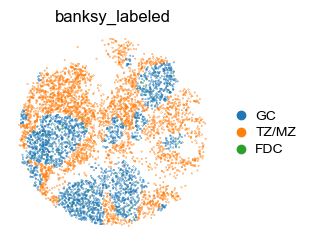

In [19]:
# adata.uns.pop('banksy_colors')

adata.obs['banksy_labeled'] = adata.obs['banksy'].map({0: 'TZ/MZ', 1: 'GC', 2: 'FDC'}.__getitem__)
adata.obs['banksy_labeled'] = adata.obs['banksy_labeled'].cat.reorder_categories(['GC', 'TZ/MZ', 'FDC'])

sq.pl.spatial_scatter(adata, color="banksy_labeled", size=.1, shape=None, legend_loc='right margin', frameon=False, figsize=(3, 3))

c:\Users\lshh\miniconda3\envs\py311_torch211_cuda121\Lib\site-packages\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


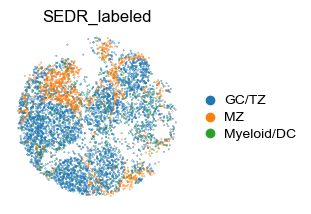

In [20]:
# adata.uns.pop('banksy_colors')
temp_df = pd.read_csv("./saved_results/slidetags_sedr_spatial_domain.csv", index_col=0)
adata.obs['SEDR'] = temp_df['slidetags_sedr_spatial_domain'].astype('category')

adata.obs['SEDR_labeled'] = adata.obs['SEDR'].map({1: 'GC/TZ', 2: 'Myeloid/DC', 3: 'MZ'}.__getitem__)
adata.obs['SEDR_labeled'] = adata.obs['SEDR_labeled'].cat.reorder_categories(['GC/TZ', 'MZ', 'Myeloid/DC'])

sq.pl.spatial_scatter(adata, color="SEDR_labeled", size=.1, shape=None, legend_loc='right margin', frameon=False, figsize=(3, 3))

c:\Users\lshh\miniconda3\envs\py311_torch211_cuda121\Lib\site-packages\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


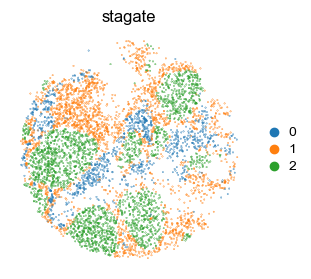

In [21]:
# adata.uns.pop('banksy_colors')
temp_df = pd.read_csv("./saved_results/tonsil_stagate_spatial_domain.csv", index_col=0)
adata.obs['stagate'] = temp_df['stagate'].astype('category')

adata.obs['stagate_labeled'] = adata.obs['stagate'].map({0: 'TZ', 1: 'MZ', 2: 'GC'}.__getitem__)
adata.obs['stagate_labeled'] = adata.obs['stagate_labeled'].cat.reorder_categories(['GC', 'TZ', 'MZ'])

sq.pl.spatial_scatter(adata, color="stagate", size=.1, shape=None, legend_loc='right margin', frameon=False, figsize=(3, 3))

In [22]:
adata.uns['steamboat_spatial_domain_2_labeled_colors'] = ['#144B99', '#CCAA7A', '#7CBDCB']
adata.uns['banksy_labeled_colors'] = ['#144B99', '#A0A0BB', '#866D2B']
adata.uns['SEDR_labeled_colors'] = ['#445BA9', '#7CBDCB', '#B33E54']
adata.uns['stagate_labeled_colors'] = ['#144B99', '#CCAA7A', '#7CBDCB']

In [ ]:
import matplotlib.font_manager as fm

vega_20_scanpy = ['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc',
                  '#8c564b', '#e377c2', '#b5bd61', '#17becf', '#aec7e8',
                  '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5', '#c49c94',
                  '#f7b6d2', '#dbdb8d', '#9edae5', '#ad494a', '#8c6d31']

def polished_spatial_scatter(adata, color, palette=None, size=.5, ax=None, rasterized=None, frameon=False, 
                             legend_loc='right margin', legend_ncols=1, legend_shift=(0,0), legend_frameon=False, legend_title=None):
    if rasterized is None:
        rasterized = adata.shape[0] > 500

    if palette is None:
        palette = vega_20_scanpy
    if isinstance(palette, list):
        palette = {cat: palette[i % len(palette)] for i, cat in enumerate(adata.obs[color].astype('category').cat.categories)}
    
    for cat in adata.obs[color].astype('category').cat.categories:
        subset = adata[adata.obs[color] == cat]
        x = subset.obsm['spatial'][:, 0]
        y = subset.obsm['spatial'][:, 1]
        x = x
        y = -y
        ax.scatter(x, y, c=palette[cat], 
                   s=size, cmap='tab20', alpha=0.8, rasterized=rasterized, label=cat, linewidths=0)
    ax.set_xticks([])
    ax.set_yticks([])
    if not frameon:
        for pos in ['right', 'top', 'left', 'bottom']:
            ax.spines[pos].set_visible(False)
    ax.set_aspect('equal')

    if legend_loc != 'off':
        if legend_loc == 'right margin':
            loc = 'center left'
            bbox_to_anchor = (1 + legend_shift[0], 0.5 + legend_shift[1])
        elif legend_loc == 'bottom margin':
            loc = 'upper center'
            bbox_to_anchor = (0.5 + legend_shift[0], -0.1 + legend_shift[1])
        
        bold_font = fm.FontProperties(size=9, weight='semibold')
        legend = ax.legend(*ax.get_legend_handles_labels(), 
                           fontsize=9, 
                           title=legend_title, title_fontproperties=bold_font,
                        loc=loc, bbox_to_anchor=bbox_to_anchor, 
                        ncol=legend_ncols, columnspacing=0.5,
                        frameon=legend_frameon, handletextpad=0.1, labelspacing=0.3)
        for handle in legend.legend_handles:
            handle.set_sizes([30])  # Adjust dot size in legend


C:\Users\lshh\AppData\Local\Temp\ipykernel_91744\4199603156.py:24: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, c=palette[cat],


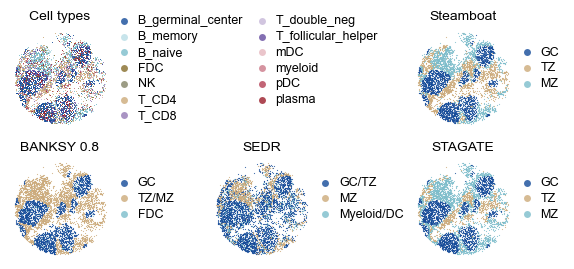

In [53]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(6.5, 3))
gs = GridSpec(2, 3, width_ratios=[1, 1, 1], hspace=.3, wspace=1., figure=fig)
axes = [fig.add_subplot(gs[0, 0]), 
        fig.add_subplot(gs[0, 2]),
        fig.add_subplot(gs[1, 0]),
        fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[1, 2]),]
##########################
ax = axes[0]
palette = adata.uns['cluster_colors']
polished_spatial_scatter(adata, color="cluster", palette=palette, size=.5, ax=ax, legend_loc='right margin',
                         legend_ncols=2, legend_shift=(-0.1, 0.1), legend_frameon=False, legend_title=None)
ax.set_title("Cell types", size=10)

#################
ax = axes[1]
palette = adata.uns['steamboat_spatial_domain_2_labeled_colors']
polished_spatial_scatter(adata, color="steamboat_spatial_domain_2_labeled", palette=palette, size=.75, ax=ax, legend_loc='right margin',
                         legend_ncols=1, legend_shift=(-0.1, 0.1), legend_frameon=False, legend_title=None)
ax.set_title("Steamboat", size=10)


####################
ax = axes[2]
polished_spatial_scatter(adata, color="banksy_labeled", palette=palette, size=.75, ax=ax, legend_loc='right margin',
                         legend_ncols=1, legend_shift=(-0.1, 0.1), legend_frameon=False, legend_title=None)
ax.set_title("BANKSY 0.8", size=10)


####################
ax = axes[3]
polished_spatial_scatter(adata, color="SEDR_labeled", palette=palette, size=.75, ax=ax, legend_loc='right margin',
                         legend_ncols=1, legend_shift=(-0.1, 0.1), legend_frameon=False, legend_title=None)
ax.set_title("SEDR", size=10)

####################
ax = axes[4]
polished_spatial_scatter(adata, color="stagate_labeled", palette=palette, size=.75, ax=ax, legend_loc='right margin',
                         legend_ncols=1, legend_shift=(-0.1, 0.1), legend_frameon=False, legend_title=None)
ax.set_title("STAGATE", size=10)

fig.savefig("figures/tonsil_spatial_domain.pdf", dpi=250, **pltkw)

adata.obs.to_csv("saved_results/tonsil_spatial_domain_all_methods.csv")

In [175]:
tmp = pd.crosstab(adata.obs['steamboat_spatial_domain_2_labeled'], adata.obs['cluster'])
# tmp.div(tmp.sum(axis=0), axis=1)
tmp

cluster,B_germinal_center,B_memory,B_naive,FDC,NK,T_CD4,T_CD8,T_double_neg,T_follicular_helper,mDC,myeloid,pDC,plasma
steamboat_spatial_domain_2_labeled,,,,,,,,,,,,,
GC,1710,18,26,121,13,22,9,0,232,0,44,2,199
TZ,72,134,148,69,129,697,177,36,41,113,38,60,19
MZ,66,364,893,65,28,60,52,10,21,24,20,2,44


In [155]:
tmp = pd.crosstab(adata.obs['banksy_labeled'], adata.obs['cluster'])

tmp.div(tmp.sum(axis=0), axis=1)

cluster,B_germinal_center,B_memory,B_naive,FDC,NK,T_CD4,T_CD8,T_double_neg,T_follicular_helper,mDC,myeloid,pDC,plasma
banksy_labeled,,,,,,,,,,,,,
TZ + MZ,0.082792,0.926357,0.921275,0.498039,0.894118,0.928113,0.882353,0.934783,0.166667,0.948905,0.509804,0.9375,0.244275
GC,0.917208,0.073643,0.078725,0.192157,0.105882,0.071887,0.117647,0.065217,0.833333,0.051095,0.490196,0.0625,0.755725
FDC,0.000000,0.000000,0.000000,0.309804,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000


In [193]:
tmp = pd.crosstab(adata.obs['SEDR'], adata.obs['cluster'])
# tmp.div(tmp.sum(axis=0), axis=1)
tmp

cluster,B_germinal_center,B_memory,B_naive,FDC,NK,T_CD4,T_CD8,T_double_neg,T_follicular_helper,mDC,myeloid,pDC,plasma
SEDR,,,,,,,,,,,,,
1,1832,167,165,56,167,777,225,46,292,13,3,9,260
2,0,0,0,191,0,0,0,0,0,121,98,55,0
3,16,349,902,8,3,2,13,0,2,3,1,0,2


In [ ]:
adata_ = adata.copy()
adata_.X = None
adata_.write_h5ad("saved_results/tonsil_steamboat_annotated.h5ad")